**Install the required libraries**

In [140]:
# Install libraries to use matminer.
!pip install pyyaml -q
!pip install six -q
!pip install matminer[citrine] -q
!pip install citrination-client -q
!pip install --upgrade pandas==2.2.2 -q
!pip install pymatgen -q
!pip install --upgrade matplotlib==3.8.0 -q

# **1. Train and Test ML algorithm: Heating and Cooling Load Case**

**Loading libraries we want to use in this notebook**

(you don't need to load all of libraries at first and you can load it anytime and anywhere)

In [141]:
import pandas as pd # a software library written for the Python programming language for data manipulation and analysis. In particular, it offers data structures and operations for manipulating numerical tables and time series
import seaborn as sns # Python data visualization library based on matplotlib. It provides a high-level interface for drawing attractive and informative statistical graphics
import numpy as np # a software library for the Python programming language, adding support for large, multi-dimensional arrays and matrices, along with a large collection of high-level mathematical functions to operate on these arrays.
import matplotlib.pyplot as plt # a plotting library for the Python programming language

# sklearn is a machine learning software library for the Python programming language. It features various classification, regression and clustering algorithms including support vector machines, random forests, gradient boosting,
# k-means and DBSCAN, and is designed to interoperate with the Python numerical and scientific libraries NumPy and SciPy.
from sklearn.datasets import fetch_openml
from sklearn import linear_model, metrics, model_selection
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import SelectKBest, f_regression

Loading the boston house-prices dataset from the sklearn repository

In [142]:
# Load the California housing dataset
Energy = pd.read_excel('ENB2012_data.xlsx')

In [143]:
# Print the key values of data
print(Energy.keys())
# Print the total row and column length of the dataset
print(Energy.shape)

Index(['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'Y1', 'Y2'], dtype='object')
(768, 10)


In [144]:
df = pd.DataFrame(Energy)
df.head()

,X1,X2,X3,X4,X5,X6,X7,X8,Y1,Y2
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55,21.33
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55,21.33
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55,21.33
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55,21.33
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84,28.28


In [145]:
rename_dict = {
    "X1": "Relative_Compactness",
    "X2": "Surface_Area",
    "X3": "Wall_Area",
    "X4": "Roof_Area",
    "X5": "Overall_Height",
    "X6": "Orientation",
    "X7": "Glazing_Area",
    "X8": "Area_Distribution",
    "Y1": "Heating_Load",
    "Y2": "Cooling_Load"
}

df = df.rename(columns=rename_dict)

print(df.head())

   Relative_Compactness  Surface_Area  Wall_Area  Roof_Area  Overall_Height  \
0                  0.98         514.5      294.0     110.25             7.0   
1                  0.98         514.5      294.0     110.25             7.0   
2                  0.98         514.5      294.0     110.25             7.0   
3                  0.98         514.5      294.0     110.25             7.0   
4                  0.90         563.5      318.5     122.50             7.0   

   Orientation  Glazing_Area  Area_Distribution  Heating_Load  Cooling_Load  
0            2           0.0                  0         15.55         21.33  
1            3           0.0                  0         15.55         21.33  
2            4           0.0                  0         15.55         21.33  
3            5           0.0                  0         15.55         21.33  
4            2           0.0                  0         20.84         28.28  


**Feature selection**

Sometimes, the input variables may not be directly related to the interested target. Hence, a feature selection step is necessary. There are many different methods for selecting features. Here we will go over a simple implementation in scikit-learn.

In [ ]:
# Function that returns feature names
def identify_columns(x_new, nrows=10):
    columns = x_data.columns
    xvalues = x_data.values
    dist = np.linalg.norm(xvalues[:nrows, :, None] - x_new[:nrows, None, :], axis=0)
    return columns[np.argmin(dist, axis=0)].values

In [147]:
x_data_set = ['Relative_Compactness', 'Surface_Area', 'Wall_Area', 'Roof_Area', 'Overall_Height', 'Orientation', 'Glazing_Area', 'Area_Distribution']
x_data = df[x_data_set]

# Target variables
y_data_1 = df['Heating_Load']
y_data_2 = df['Cooling_Load']

In [148]:
# Select the top 5 features by using 'SelectKBest'
sel = SelectKBest(f_regression, k=5)
x_new = sel.fit_transform(x_data, y_data_1)
print(f"Selected features {identify_columns(x_new)}")

Selected features ['Relative_Compactness' 'Surface_Area' 'Wall_Area' 'Roof_Area'
 'Overall_Height']


**1. Train ML algorithm**

/tmp/ipykernel_1261/1686032819.py:12: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.text(1.6, 4, "Y1 = {:.3f} * X1 + {:.3f}".format(float(a), float(b)) , fontsize=15, color = "r")


Text(1.6, 4, 'Y1 = 59.359 * X1 + -23.053')

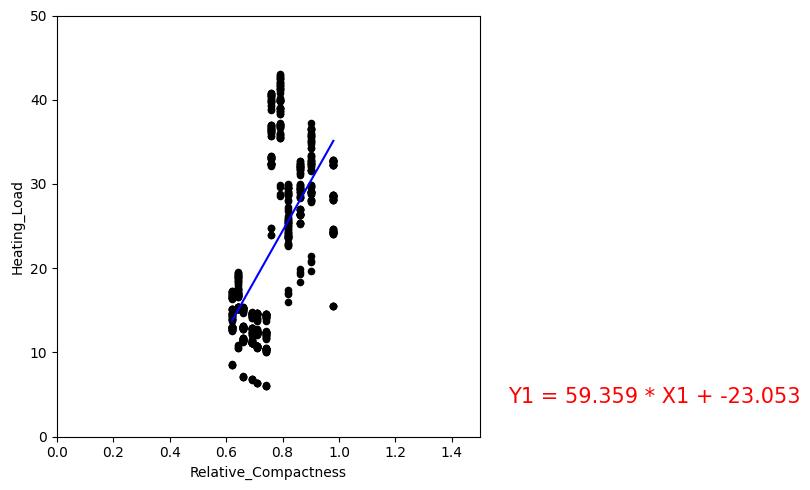

In [149]:
# Train about the average number of rooms and house quality by using 'LinearRegression'
linear_regression = linear_model.LinearRegression()
linear_regression.fit(X=pd.DataFrame(df['Relative_Compactness']), y=df['Heating_Load'])
prediction = linear_regression.predict(X=pd.DataFrame(df['Relative_Compactness']))

# Get the slope and intercept from the trained linear regression model
a = linear_regression.coef_
b = linear_regression.intercept_
df.plot(kind='scatter', x ="Relative_Compactness", y="Heating_Load", figsize=(5, 5), color='black', xlim=(0,1.5), ylim=(0,50))
plt.tight_layout()
plt.plot(df['Relative_Compactness'], prediction, color='b')
plt.text(1.6, 4, "Y1 = {:.3f} * X1 + {:.3f}".format(float(a), float(b)) , fontsize=15, color = "r") 

**2. Train & Test ML algorithm**



In [150]:
# Classify into training dataset and testing dataset using only "Surface_Area" feature
x_data = df[['Surface_Area']]
y_data = df['Heating_Load']

# Split the data into training and test sets('train_test_split')
x_train, x_test, y_train, y_test = model_selection.train_test_split(x_data, y_data, test_size=0.1)
print("Size of training set: {}, test set: {}".format(len(x_train), len(x_test)))

Size of training set: 691, test set: 77


score: 0.35
Mean Squared Error: 65.80
RMSE (* 1000$): 8.11


(0.0, 50.0)

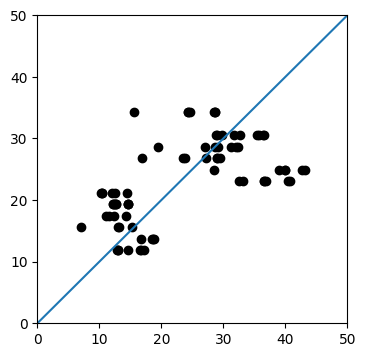

In [151]:
# Train Linear regression model('fit')
estimator = linear_model.LinearRegression()
estimator.fit(X=x_train, y=y_train)

# Test with prediction by using R2 score('metrics.r2_score')
y_predict_test = estimator.predict(x_test)
score = metrics.r2_score(y_test, y_predict_test)

print('score: {:.2f}'.format(float(score)))
print('Mean Squared Error: {:.2f}'.format(metrics.mean_squared_error(y_predict_test, y_test)))
print('RMSE (* 1000$): {:.2f}'.format(metrics.mean_squared_error(y_predict_test, y_test)**.5))

# Print prediction values about test set
plt.figure(figsize=(4,4))
plt.scatter(y_test, y_predict_test, color='k')
plt.plot([0,50],[0,50])
plt.xlim(0, 50)
plt.ylim(0, 50)

score: 0.94
Mean Squared Error: 5.99
RMSE (* 1000$): 2.45


(0.0, 50.0)

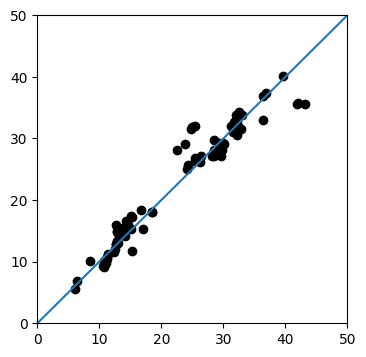

In [152]:
# Train with all features('california.feature_names')
x_data = df[x_data_set]
y_data = df['Heating_Load']
x_train, x_test, y_train, y_test = model_selection.train_test_split(x_data, y_data, test_size=0.1)

estimator = linear_model.LinearRegression()
estimator.fit(x_train, y_train)

#y_predict_train = estimator.predict(x_train)
#score = metrics.r2_score(y_train, y_predict_train)
#print(score) #1.0

y_predict_test = estimator.predict(x_test)
score = metrics.r2_score(y_test, y_predict_test)

print('score: {:.2f}'.format(float(score)))
print('Mean Squared Error: {:.2f}'.format(metrics.mean_squared_error(y_predict_test, y_test)))
print('RMSE (* 1000$): {:.2f}'.format(metrics.mean_squared_error(y_predict_test, y_test)**.5))

plt.figure(figsize=(4,4))
plt.scatter(y_test, y_predict_test, color='k')
plt.plot([0,50],[0,50])
plt.xlim(0, 50)
plt.ylim(0, 50)

Benchmark the optimial number of features

In [169]:
import pandas as pd
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn import metrics

# 1. 데이터 준비
x_data = df[x_data_set]
y_data = df['Heating_Load']

# 2. train/val + test 먼저 나누기 (test는 최종 평가용)
X_trainval, X_test, y_trainval, y_test = train_test_split(
    x_data, y_data, test_size=0.2, random_state=42
)

# 3. 파이프라인 정의 (feature selection + regression)
pipeline = Pipeline([
    ('feature_selection', SelectKBest(score_func=f_regression)),
    ('regression', LinearRegression())
])

# 4. GridSearchCV로 최적 feature 개수 탐색 (train/val 데이터만 사용)
param_grid = {
    'feature_selection__k': list(range(1, len(x_data.columns)+1))
}
grid = GridSearchCV(pipeline, param_grid, cv=5, scoring='r2')
grid.fit(X_trainval, y_trainval)

print("Best number of features (from validation):", grid.best_params_['feature_selection__k'])
print("Best cross-validation R2 (validation only):", grid.best_score_)

# 5. 최적 feature 확인
best_selector = grid.best_estimator_.named_steps['feature_selection']
selected_features = X_trainval.columns[best_selector.get_support()]
print("Selected features:", list(selected_features))

# 6. 최적 모델로 train+val 전체 학습 후, 최종 test dataset 평가
final_model = grid.best_estimator_
final_model.fit(X_trainval, y_trainval)

y_pred_test = final_model.predict(X_test)
print("\nFinal Test R2:", metrics.r2_score(y_test, y_pred_test))
print("Final Test MSE:", metrics.mean_squared_error(y_test, y_pred_test))
print("Final Test RMSE:", metrics.mean_squared_error(y_test, y_pred_test) ** 0.5)


Best number of features (from validation): 7
Best cross-validation R2 (validation only): 0.9147437931345422
Selected features: ['Relative_Compactness', 'Surface_Area', 'Wall_Area', 'Roof_Area', 'Overall_Height', 'Glazing_Area', 'Area_Distribution']

Final Test R2: 0.9122131164945247
Final Test MSE: 9.150238371119471
Final Test RMSE: 3.024936093724869


In [168]:
import pandas as pd
from sklearn import model_selection, linear_model, metrics
from sklearn.feature_selection import SelectKBest, f_regression
import matplotlib.pyplot as plt

# 1. 데이터 준비
x_data = df[x_data_set]
y_data = df['Heating_Load']

# 2. train/test 먼저 나누기 (test는 따로 보관)
X_trainval, X_test, y_trainval, y_test = model_selection.train_test_split(
    x_data, y_data, test_size=0.2, random_state=42
)

all_scores = []

# 3. feature 개수 바꿔가면서 학습 + validation
for i in range(1, len(x_data_set)+1):
    sel = SelectKBest(f_regression, k=i)
    X_new = sel.fit_transform(X_trainval, y_trainval)
    selected = x_data.columns[sel.get_support()]

    print(f"\nSelected {i} features: {list(selected)}")

    # 반복 validation 성능 저장
    sum_score = 0
    for j in range(200):  # 여러 번 split해서 평균냄
        X_train, X_val, y_train, y_val = model_selection.train_test_split(
            X_trainval[selected], y_trainval, test_size=0.2
        )
        estimator = linear_model.LinearRegression()
        estimator.fit(X_train, y_train)
        y_pred_val = estimator.predict(X_val)
        sum_score += metrics.r2_score(y_val, y_pred_val)

    avg_score = sum_score / 200
    all_scores.append(avg_score)
    print(f"Avg validation R2 at step {i}: {avg_score:.3f}")

# 4. 최적 feature 개수 선택
best_k = all_scores.index(max(all_scores)) + 1
print(f"\nBest number of features = {best_k}")

# 5. 최적 feature로 train+val 전체 데이터 학습
sel = SelectKBest(f_regression, k=best_k)
X_trainval_new = sel.fit_transform(X_trainval, y_trainval)
selected = x_data.columns[sel.get_support()]
final_model = linear_model.LinearRegression()
final_model.fit(X_trainval[selected], y_trainval)

# 6. 최종 test dataset 평가
y_pred_test = final_model.predict(X_test[selected])
print("\nFinal Test R2:", metrics.r2_score(y_test, y_pred_test))
print("Final Test MSE:", metrics.mean_squared_error(y_test, y_pred_test))



Selected 1 features: ['Overall_Height']
Avg validation R2 at step 1: 0.789

Selected 2 features: ['Roof_Area', 'Overall_Height']
Avg validation R2 at step 2: 0.786

Selected 3 features: ['Surface_Area', 'Roof_Area', 'Overall_Height']
Avg validation R2 at step 3: 0.830

Selected 4 features: ['Relative_Compactness', 'Surface_Area', 'Roof_Area', 'Overall_Height']
Avg validation R2 at step 4: 0.834

Selected 5 features: ['Relative_Compactness', 'Surface_Area', 'Wall_Area', 'Roof_Area', 'Overall_Height']
Avg validation R2 at step 5: 0.835

Selected 6 features: ['Relative_Compactness', 'Surface_Area', 'Wall_Area', 'Roof_Area', 'Overall_Height', 'Glazing_Area']
Avg validation R2 at step 6: 0.913

Selected 7 features: ['Relative_Compactness', 'Surface_Area', 'Wall_Area', 'Roof_Area', 'Overall_Height', 'Glazing_Area', 'Area_Distribution']
Avg validation R2 at step 7: 0.915

Selected 8 features: ['Relative_Compactness', 'Surface_Area', 'Wall_Area', 'Roof_Area', 'Overall_Height', 'Orientation', 

**Benchmark the score (R2) with other various regression ML algorithm (LASSO, Ridge, Random Forest Tree)**

R2 score—varies between 0 and 100%. It is closely related to the mean square error, but not the same. R2 is the proportion of the variance in the dependent variable that is predictable from the independent variable(s). Another definition is “(total variance explained by model) / total variance.” So if it is 100%, the two variables are perfectly correlated, i.e., with no variance at all. A low value would show a low level of correlation, meaning a regression model that is not valid , but not in all cases.

Selected 1 features ['Overall_Height']
average of score: 78.93
average of Mean Squared Error: 2125.82
average of RMSE (* 1000$): 459.44
Selected 2 features ['Roof_Area' 'Overall_Height']
average of score: 77.76
average of Mean Squared Error: 2252.24
average of RMSE (* 1000$): 472.67
Selected 3 features ['Surface_Area' 'Roof_Area' 'Overall_Height']
average of score: 82.76
average of Mean Squared Error: 1744.64
average of RMSE (* 1000$): 415.76
Selected 4 features ['Relative_Compactness' 'Surface_Area' 'Roof_Area' 'Overall_Height']
average of score: 82.87
average of Mean Squared Error: 1729.56
average of RMSE (* 1000$): 413.92
Selected 5 features ['Relative_Compactness' 'Surface_Area' 'Wall_Area' 'Roof_Area'
 'Overall_Height']
average of score: 82.75
average of Mean Squared Error: 1739.86
average of RMSE (* 1000$): 415.10
Selected 6 features ['Relative_Compactness' 'Surface_Area' 'Wall_Area' 'Roof_Area'
 'Overall_Height' 'Glazing_Area']
average of score: 83.09
average of Mean Squared Err

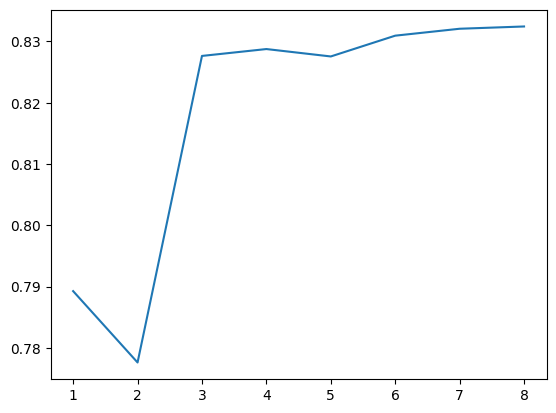

In [171]:
all = []
for i in range(1,len(x_data_set)+1):
  sum_score = 0
  sum_mse = 0
  sum_rmse = 0
  x_data = df[x_data_set]
  y_data = df['Heating_Load']
  sel = SelectKBest(f_regression, k=i)
  x_new = sel.fit_transform(x_data, y_data)
  selected = identify_columns(x_new)
  print(f"Selected {i} features {selected}")
  x_data = df[selected]
  y_data = df['Heating_Load']
  for j in range(1001):
    x_train, x_test, y_train, y_test = model_selection.train_test_split(x_data, y_data, test_size=0.1)
    # For 'Lasso' regression
    estimator = linear_model.Lasso(alpha=0.35, max_iter=1000, tol=0.0001)
    #estimator = linear_model.Ridge(alpha=1)  # For Ridge regression
    #estimator = RandomForestRegressor()  # For Random forest regressor
    estimator.fit(x_train, y_train)
    y_predict_test = estimator.predict(x_test)
    sum_score += float(metrics.r2_score(y_test, y_predict_test))
    sum_mse += float(metrics.mean_squared_error(y_predict_test, y_test))
    sum_rmse += float(metrics.mean_squared_error(y_predict_test, y_test)**.5)
  print('average of score: {:.2f}'.format(sum_score/10))
  print('average of Mean Squared Error: {:.2f}'.format(sum_mse/10))
  print('average of RMSE (* 1000$): {:.2f}'.format(sum_rmse/10))
  all.append(sum_score/1000)
plt.plot([i for i in range(1, len(all)+1)], all)

/home/seungjobaek/miniconda3/envs/Class_Practice/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


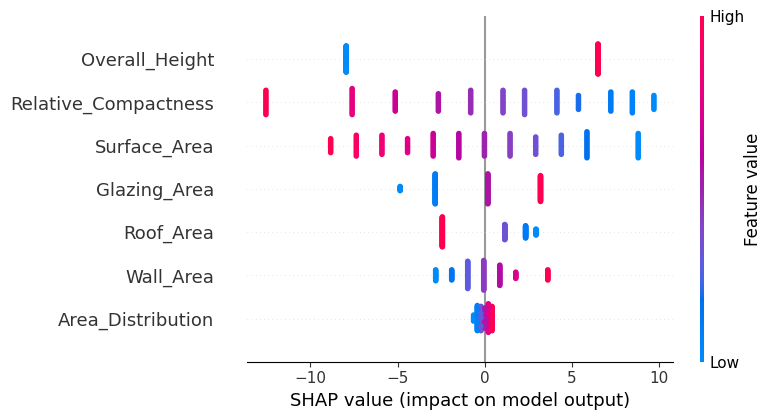

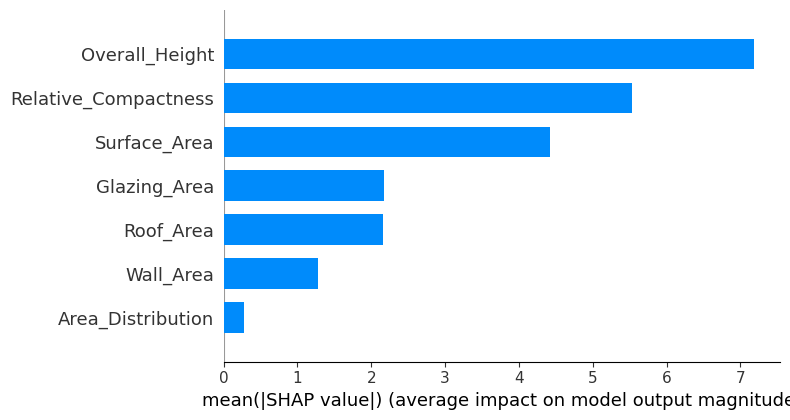

In [170]:
import shap

# 1. 최종 학습된 모델 (grid.best_estimator_) 준비
final_model = grid.best_estimator_
final_model.fit(X_trainval, y_trainval)

# 2. 선택된 feature만 가져오기
X_test_selected = X_test[selected_features]

# 3. SHAP explainer 생성 (선형 모델용)
explainer = shap.Explainer(final_model['regression'], X_test_selected)

# 4. SHAP 값 계산
shap_values = explainer(X_test_selected)

# 5. 시각화
shap.summary_plot(shap_values, X_test_selected)        # 전체 중요도 요약
shap.summary_plot(shap_values, X_test_selected, plot_type="bar")  # bar chart
